<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/banner_IA.png"  width="1000px" height="200px">

# **Taller 07: Genetic algorithms**

## **Outline**

1. [Ejercicio 1. G.A. cost function](#eje1)
2. [Ejercicio 2. G.A. crossover function](#eje2)





In [ ]:
#@title 1. MONTAR EL DRIVE **student** { display-mode: "form" }
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/course-IA1/ai-uis-student/talleres20202')
print(os.getcwd())
!chmod 777 convert_ipynb.sh run utils/

---
#### - Usted debe ejecutar **TODAS** las celdas de tipo **CODE**. De lo contrario, sus respuestas no serán procesadas correctamente.

---

# **Algoritmos Geneticos: Comunicación en una mesa redonda**


Un grupo de 300 personas de diferentes países se sienta en una mesa circular con 300 sillas. Cada persona sabe hablar dos idiomas (no necesariamente los mismos para todos). Los idiomas se codificarán de la siguiente manera:

*   0: Español
*   1: Inglés
*   2: Alemán
*   3: Francés
*   4: Portugués
*   5: Mandarín
*   6: Coreano
*   7: Noruego
*   8: Italiano
*   9: Persa
*   10: Árabe

Para este taller una mesa se codifica como un arreglo de 300 posiciones, y en cada posición (silla de la mesa) existe una lista de los dos posibles idiomas. Observe la siguiente ilustración.

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/raw/master/talleres20202/misc/mesaredonda01.png" />

Vamos a generar una **_buena_** solución para que se encuentre una disposición de las personas en la mesa de manera que cada persona pueda comunicarse con sus dos vecinos en la mesa.

- Tenga en cuenta que cada persona debe hablar dos idiomas **diferentes**. Es decir, si $(x_i, x_j)$ es la dupla de idiomas hablados por la persona, se tiene que cumplir que: $\enspace$ $x_i \neq x_j$

Para los siguientes puntos, la mesa redonda se simulará con el siguiente arreglo, donde cada solución es una permutación de los indices de la mesa. 

[216 126 185 139  57  25 283   6 112   3   5  79  18  31  84 292  98 173
 135 164 239 162  52 131 265 178 172 215 171 169 272  67 248 262 299  51
  38 255 114 293 157 111 145  53 273 233 106 228 128 149 186 102 118 121
 298 188 197  83 254  62 281 263 204 174 196   9  65   7  71  80  32 205
 130 163  13 175 284 243 115  48 222 123 287 158 289 104 129 232 113  97
 182   0 141  35 276 259 290 275  70  95  60  56 209   8   2  47 119 127
 247  34  81 156 271 168  89 295 192 211 258  90  75 147 253 176 202 159
 296 229 291 207 282 278  58 242 252  42  36 103 110 154 146 153 184  64
 268 194 285  96 124 250  20 144  61 140 122 148  24  72 161 152 246 249
 143 165  41  15 105 190  63 193 137 160  99 180 286  69  14  88 270 201
 155 199  23 288 230 240 256  16  39  74 191 138  26 231 181  43  10  92
  87 223 150 187  19 107  93 214 218  76  54 237 109  91 264 219 217 280
 227 245 267  30 151  21  29  17 208  94  37 226 108 225 189   1  73 166
  50  22  59  46 125 170 235 132 261 183 238 266  5

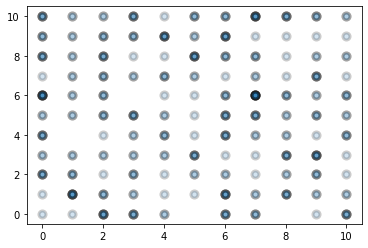

In [4]:
#@title **code** codificación de la mesa y dos posibles soluciones
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Generamos 300 personas con sus dos idiomas hablados
mesa_redonda = np.array([[5, 3], [6, 5], [2, 9], [10, 8], [5, 3], [7, 10], [1, 6], [7, 5], [4, 5], [9, 5], [4, 9], [3, 10], [0, 3], [5, 6], [4, 3], [5, 1], [0, 2], [6, 9], [3, 0], [3, 7], [8, 2], [1, 6], [7, 8], [2, 0], [6, 1], [3, 4], [8, 5], [9, 3], [6, 9], [10, 10], [10, 4], [1, 1], [8, 10], [7, 0], [3, 10], [6, 2], [5, 4], [3, 9], [5, 8], [10, 0], [1, 8], [4, 7], [1, 1], [1, 5], [8, 8], [9, 2], [3, 5], [5, 8], [7, 9], [8, 6], [10, 10], [4, 6], [0, 8], [6, 4], [0, 10], [8, 3], [8, 6], [7, 6], [8, 2], [0, 10], [7, 10], [5, 5], [2, 5], [4, 8], [7, 7], [7, 1], [2, 1], [9, 5], [0, 9], [9, 5], [7, 5], [0, 9], [6, 9], [7, 2], [2, 7], [9, 6], [6, 4], [2, 0], [6, 7], [10, 0], [2, 7], [7, 6], [0, 5], [0, 4], [6, 8], [2, 3], [9, 3], [10, 2], [7, 10], [4, 0], [2, 5], [10, 8], [6, 0], [2, 9], [0, 6], [0, 0], [6, 10], [1, 3], [4, 7], [6, 2], [3, 1], [2, 7], [3, 5], [4, 9], [8, 9], [5, 7], [2, 10], [9, 7], [3, 10], [2, 6], [6, 6], [2, 6], [1, 1], [7, 6], [2, 4], [6, 1], [7, 4], [1, 8], [3, 9], [9, 9], [5, 2], [7, 3], [10, 4], [3, 5], [8, 1], [2, 0], [7, 8], [2, 1], [1, 1], [9, 3], [8, 4], [10, 7], [1, 3], [1, 7], [7, 6], [3, 3], [7, 6], [7, 10], [6, 1], [3, 1], [0, 10], [4, 10], [7, 0], [6, 6], [9, 4], [2, 8], [6, 0], [2, 6], [8, 3], [6, 3], [9, 6], [0, 6], [7, 6], [10, 5], [0, 8], [1, 10], [1, 0], [0, 4], [3, 7], [8, 5], [6, 4], [1, 5], [9, 0], [4, 9], [5, 8], [7, 10], [0, 4], [9, 10], [8, 3], [3, 2], [8, 1], [1, 1], [2, 2], [2, 10], [5, 2], [3, 9], [2, 0], [7, 5], [7, 6], [5, 10], [0, 2], [5, 10], [6, 9], [7, 10], [6, 1], [6, 10], [2, 9], [10, 9], [1, 9], [7, 5], [10, 3], [2, 5], [0, 6], [3, 0], [7, 8], [9, 1], [5, 9], [1, 1], [9, 7], [0, 9], [8, 10], [1, 10], [3, 8], [8, 1], [8, 7], [8, 10], [3, 2], [5, 10], [3, 10], [8, 6], [8, 3], [3, 3], [7, 6], [9, 10], [4, 5], [6, 5], [6, 4], [3, 0], [6, 0], [6, 8], [4, 4], [0, 1], [0, 6], [9, 7], [9, 10], [0, 10], [0, 8], [7, 4], [1, 2], [6, 5], [2, 1], [0, 3], [10, 4], [0, 6], [5, 9], [6, 9], [1, 7], [3, 2], [9, 2], [10, 5], [4, 7], [10, 0], [3, 5], [4, 0], [8, 4], [4, 1], [3, 0], [7, 0], [10, 6], [6, 10], [6, 0], [2, 8], [7, 6], [5, 8], [5, 7], [6, 8], [2, 3], [5, 3], [7, 7], [4, 4], [6, 5], [4, 4], [1, 9], [9, 8], [9, 3], [0, 6], [2, 8], [0, 2], [10, 0], [0, 2], [8, 1], [0, 4], [1, 2], [9, 1], [10, 1], [5, 8], [4, 9], [9, 7], [5, 3], [10, 6], [10, 6], [8, 10], [9, 2], [4, 3], [0, 6], [3, 4], [4, 9], [4, 2], [0, 7], [6, 6], [6, 1], [2, 8], [10, 1], [1, 2], [2, 0], [9, 8], [0, 8], [9, 3], [0, 5], [7, 1]])
n_personas = len(mesa_redonda)

plt.scatter(mesa_redonda[:,0], mesa_redonda[:,1], s=50, alpha=0.2, edgecolors="black", linewidths=3)

solucion1 = np.random.permutation(n_personas)
solucion2 = np.random.permutation(n_personas)

print(solucion1)
print(solucion2)

# **Inicializar población**  <a name="eje1"></a>

Podemos usar la misma función de inicialización vista en clase, teniendo en cuenta que la codificación de las soluciones se simplifica a mutaciones. Entonces usaremos la siguiente función


In [5]:
#@title **code** generación de posibles formas de sentarse
def TSP_initialize_population1(n_individuals, n_personas):
    r = []
    for i in range(n_individuals):
        r.append(np.random.permutation(n_personas))
    return np.array(r)

# **Ejercicio 1. G.A. cost function**  <a name="eje1"></a>

Complete la función de costo ````TSP_cost1```` para ponderar cada solución teniendo en cuenta el número de vecinos que pueden hablarse, de la siguiente manera:

- Si no es posible hablar el mismo idioma que ambos vecinos, la función de costo debe incrementar 100 unidades.
- De lo contrario, la función de costo debe incrementar solamente 1 unidad.
- Tenga en cuenta los índices que corresponden a la primera posición (índice 0) y a la última posición (índice 299) son considerados **VECINOS**.


**Recomendación:** para simplificar el problema, valide que CUALQUIERA de los dos idiomas hablados por la persona SIGUIENTE, sea el mismo que CUALQUIERA de los dos idiomas que habla la persona actual.



In [ ]:
#@title **Escriba su código aquí!**
#@markdown No modifique las dos últimas lineas

def TSP_cost1(personas, solution):
    costo = 0
    sol_personas = personas[solution]
    for i in range(sol_personas.shape[0]):
     


     
    return costo



import urllib.parse, inspect
src1 = urllib.parse.quote_plus(inspect.getsource(TSP_cost1))

In [ ]:
#@title **Evalue su respuesta.**
!./run CHECK_SOLUTION PS7_1 $src1

# **Ejercicio 2. G.A. crossover function**  <a name="eje2"></a>

Ahora vamos a generar una función de crossover que obtenga **cuatro hijos** por cada pareja de soluciones que se ingresan, utilizando la configuración descrita en la figura: 


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/-/raw/master/talleres20202/misc/mesaredonda02.png" />

In [ ]:
#@title **Escriba su código aquí!**
#@markdown No modifique las dos últimas lineas

def TSP_cross_over_1(solution1, solution2):
    l = len(solution1)
    fp = ?


    return r[0], r[1], r[2], r[3]


#Colaboratory
import urllib.parse, inspect
src2 = urllib.parse.quote_plus(inspect.getsource(TSP_cross_over_1))

In [ ]:
#@title **Evalue su respuesta.**
!./run CHECK_SOLUTION PS7_2 $src2

In [10]:
#@title **Verifique su solución**

sol1 = np.random.permutation(20)
sol2 = np.random.permutation(20)
print(sol1)
print(sol2)


hijos = TSP_cross_over_1(sol1, sol2)
print(hijos[0])
print(hijos[1])
print(hijos[2])
print(hijos[3])

[16  7 10  4  2 18 19  5 11  9  1 17  6  8 12  0 15 14  3 13]
[ 6 16 18 19  3 12  5  1  2  4 11  0 13 10  7  8 17  9 14 15]
[16.  7. 10.  4.  6. 18. 19.  3. 12.  5.  1.  2. 11.  0. 13.  8. 17.  9.
 14. 15.]
[ 6. 16. 18. 19.  7. 10.  4.  2.  5. 11.  9.  1. 17.  8. 12.  0. 15. 14.
  3. 13.]
[15. 14.  3. 13.  6. 16. 18. 19. 12.  5.  1.  2.  4. 11.  0. 10.  7.  8.
 17.  9.]
[17.  9. 14. 15. 16.  7. 10.  4.  2. 18. 19.  5. 11.  1.  6.  8. 12.  0.
  3. 13.]


Teniendo en cuenta la codificación del problema, podemos usar las funciones de mutación que vimos en clase.

In [11]:
#@title **code** mutation
def TSP_mutate1(solution, mutation_prob):
    mutated_solution = np.copy(solution)
    for i in range(len(solution)):
        if np.random.random()<mutation_prob:
            j = i+1 if i!=len(solution)-1 else 0
            tmp = mutated_solution[i]
            mutated_solution[i] = mutated_solution[j]
            mutated_solution[j] = tmp
    return mutated_solution

Finalmente, observe el funcionamiento del algoritmo genético:

In [ ]:
#@title **verifique su respuesta**
import numpy as np

def TSP_plot_GA_result(best, bests, means, stds):
    fig = plt.figure(figsize=(12,4))
    fig.add_subplot(121)
    plot_evolution(bests, means, stds)


%run ga4.py

r = run_ga(pop_size=10, 
               init_population_function = lambda x: TSP_initialize_population1(x, n_personas), 
               mutation_function        = TSP_mutate1, 
               crossover_function       = TSP_cross_over_1,
               cost_function            = lambda x: TSP_cost1(mesa_redonda, x), 
               crossover_prob           = 0.001,
               mutation_prob            = 0.001, 
               n_iters                  = 1500)

best, best_costs, means, stds = r
TSP_plot_GA_result(best, best_costs, means, stds)
print("Orden de los indices", best)
print("Secuencia en la que se deben sentar las personas \n", mesa_redonda[best].tolist())

<br><br><br><br>

# **Pasos Finales.**



#### 1. Reemplace la variable con su código de estudiante

In [ ]:
#@title **1. Complete la siguiente información:**
taller_name = "Taller_std_07_20202" #@param {type:"string"}
codigo_name = "tl7_12345" #@param {type:"string"}


import urllib.parse, inspect
taller = urllib.parse.quote_plus(taller_name)
codigo = urllib.parse.quote_plus(codigo_name)

print(taller, codigo)

In [ ]:
#@title **2. Guarde los cambios del taller**
%%javascript
require(["base/js/namespace"],function(Jupyter) {
    Jupyter.notebook.save_checkpoint();
});

In [ ]:
#@title **3. Ejecute la siguiente celda y envíe el archivo**
!./convert_ipynb.sh $codigo $taller

---
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/bannerThanks.jpg" alt="Drawing" style="width:700px;"/>